In [1]:
import numpy as np 
import matplotlib.pyplot as plt


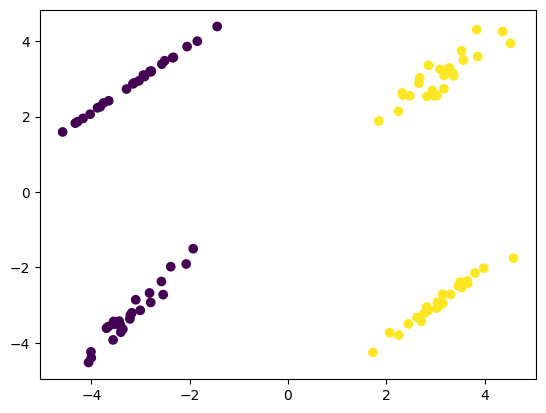

In [40]:
from sklearn.datasets import make_classification
X,Y=make_classification(n_samples=100,n_features=2,n_classes=2,n_redundant=0,n_informative=2,random_state=42,class_sep=3)
plt.scatter(X[:,0],X[:,1],c=Y)
plt.show()


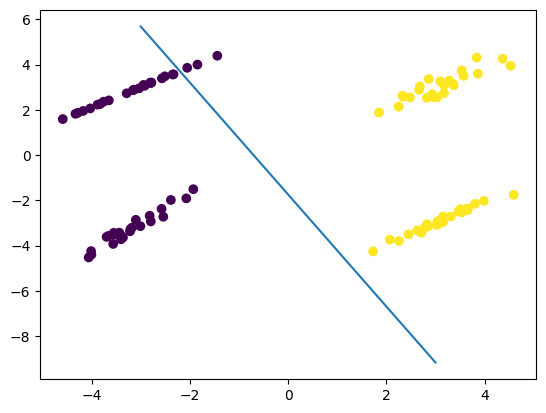

In [41]:
# precepton method
import random
def step(z):
    return 1 if z>0 else 0
class log_p():

    def __init__(self,lrr=0.01,epoch=200):
        self.lrr=lrr
        self.weights = None
        self.epoch=epoch

    def fit(self,X,Y):
        X = np.insert(X,0,1,axis=1)
        self.weights = np.ones(X.shape[1])
        for i in range(self.epoch):
            j = np.random.randint(0,100)
            y_hat = step(np.dot(X[j],self.weights))
            self.weights = self.weights + self.lrr*(Y[j]-y_hat)*X[j]
   
model=log_p()
model.fit(X,Y)
model.weights
m=-model.weights[1]/model.weights[2]
c=-model.weights[0]/model.weights[2]
x=np.linspace(-3,3,100)
y=m*x+c
plt.scatter(X[:,0],X[:,1],c=Y)
plt.plot(x,y)








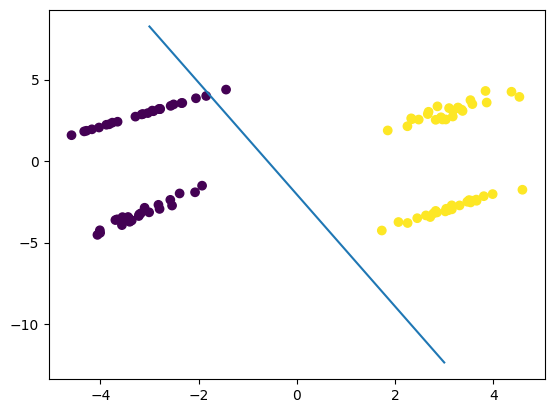

In [42]:
# changing the step function to sigmoid function
def sigmoid(z):
    return 1/(1+np.exp(-z))
class log_p_sig():

    def __init__(self,lrr=0.01,epoch=200):
        self.lrr=lrr
        self.weights = None
        self.epoch=epoch

    def fit(self,X,Y):
        X = np.insert(X,0,1,axis=1)
        self.weights = np.ones(X.shape[1])
        for i in range(self.epoch):
            j = np.random.randint(0,100)
            y_hat = sigmoid(np.dot(X[j],self.weights))
            self.weights = self.weights + self.lrr*(Y[j]-y_hat)*X[j]

model=log_p_sig()
model.fit(X,Y)
model.weights
m2=-model.weights[1]/model.weights[2]
c2=-model.weights[0]/model.weights[2]
x_l_s=np.linspace(-3,3,100)
y_l_s=m2*x_l_s+c2
plt.scatter(X[:,0],X[:,1],c=Y)
plt.plot(x_l_s,y_l_s)


In [ ]:
# actual logistic regression use gradient descent method to adjust weight with sigmoid function

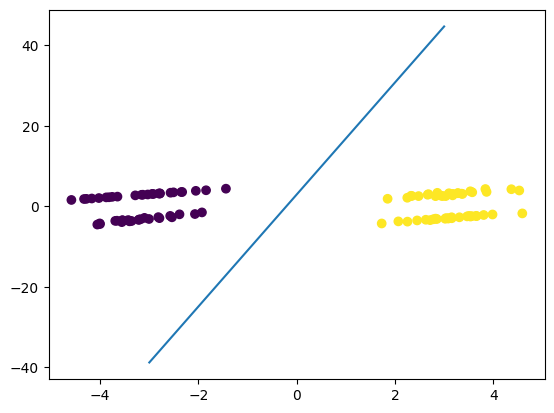

In [43]:
class log():
    def __init__(self,lrr=0.01,epoch=200):
        self.lrr=lrr
        self.weights = None
        self.epoch=epoch

    def fit(self,X,Y):
        X = np.insert(X,0,1,axis=1)
        self.weights = np.ones(X.shape[1])
        for i in range(self.epoch):
            y_hat = 1/(1+np.exp(-X.dot(self.weights)))
            self.weights = self.weights + self.lrr*(Y-y_hat).dot(X)
model=log()
model.fit(X,Y)
model.weights
m3=-model.weights[1]/model.weights[2]
b3=-model.weights[0]/model.weights[2]
x_l=np.linspace(-3,3,100)
y_l=m3*x_l+b3
plt.scatter(X[:,0],X[:,1],c=Y)
plt.plot(x_l,y_l)

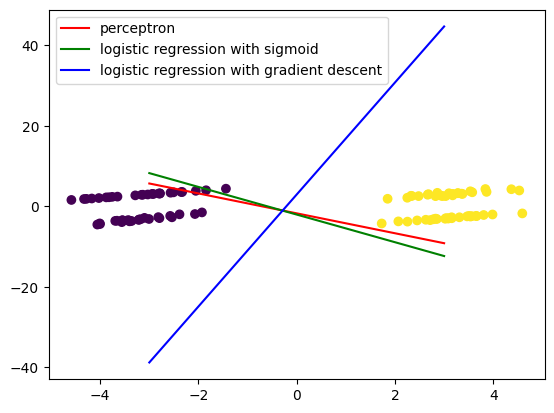

In [44]:
plt.plot(x,y,label='perceptron',color='red')
plt.plot(x_l_s,y_l_s,label='logistic regression with sigmoid',color='green')
plt.plot(x_l,y_l,label='logistic regression with gradient descent',color='blue')
plt.scatter(X[:,0],X[:,1],c=Y)
plt.legend()
